In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import savgol_filter
import glob
import pickle
from datetime import datetime
from tqdm import tqdm
from signal_changes import *
from signal_changes import *
%load_ext autoreload
%autoreload 2

/tmp/ipykernel_2737617/640327640.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
sys.path.append(os.path.join("..", "..", "..", "pybmi"))

['2021-07-16_preprocess.pkl', '2021-11-29_preprocess.pkl', '2023-06-16_preprocess.pkl', '2021-09-06_preprocess.pkl', '2023-04-05_preprocess.pkl', '2020-03-19_preprocess.pkl', '2021-03-13_preprocess.pkl', '2021-04-02_preprocess.pkl', '2021-08-23_preprocess.pkl', '2022-02-25_preprocess.pkl', '2020-03-18_preprocess.pkl', '2020-08-29_preprocess.pkl', '2022-09-06_preprocess.pkl', '2020-03-13_preprocess.pkl', '2022-10-25_preprocess.pkl', '2021-03-09_preprocess.pkl', '2022-09-09_preprocess.pkl', '2023-02-13_preprocess.pkl', '2021-02-23_preprocess.pkl', '2022-03-31_preprocess.pkl', '2021-03-12_preprocess.pkl', '2023-03-17_preprocess.pkl', '2021-08-27_preprocess.pkl', '2022-04-21_preprocess.pkl', '2021-04-21_preprocess.pkl', '2020-09-04_preprocess.pkl', '2022-01-26_preprocess.pkl', '2021-04-09_preprocess.pkl', '2021-11-01_preprocess.pkl', '2021-05-04_preprocess.pkl', '2023-02-20_preprocess.pkl', '2020-07-29_preprocess.pkl', '2022-04-08_preprocess.pkl', '2021-06-04_preprocess.pkl', '2021-08-31_p

100%|██████████| 303/303 [00:03<00:00, 86.52it/s]
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperl

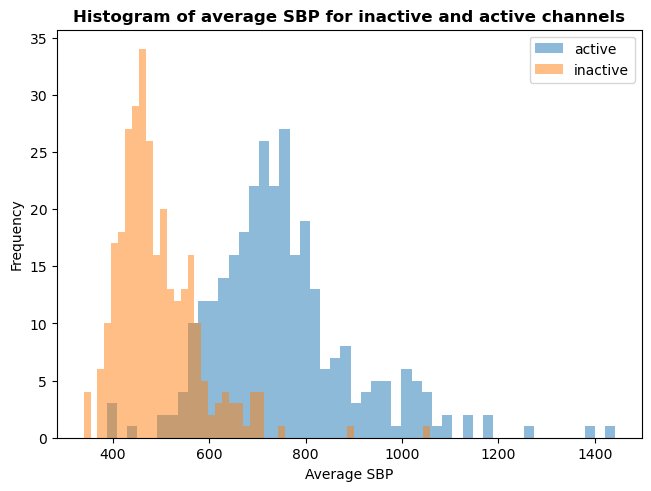

findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson

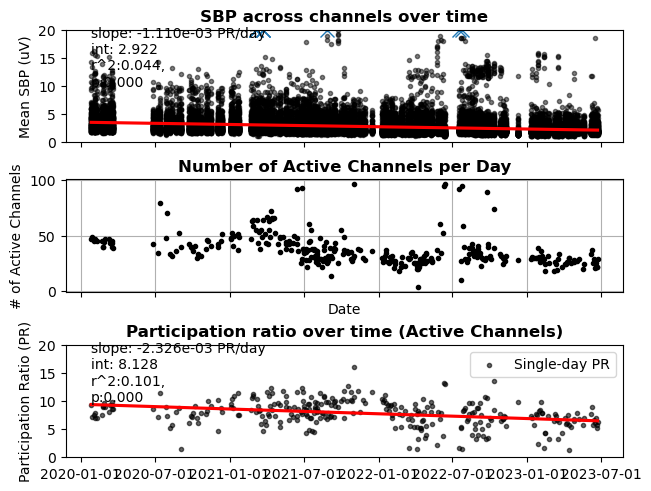

In [3]:
create_signal_quality_figure(calc_avg_sbp=True, annotate=True)


['2021-07-16_preprocess.pkl', '2021-11-29_preprocess.pkl', '2023-06-16_preprocess.pkl', '2021-09-06_preprocess.pkl', '2023-04-05_preprocess.pkl', '2020-03-19_preprocess.pkl', '2021-03-13_preprocess.pkl', '2021-04-02_preprocess.pkl', '2021-08-23_preprocess.pkl', '2022-02-25_preprocess.pkl', '2020-03-18_preprocess.pkl', '2020-08-29_preprocess.pkl', '2022-09-06_preprocess.pkl', '2020-03-13_preprocess.pkl', '2022-10-25_preprocess.pkl', '2021-03-09_preprocess.pkl', '2022-09-09_preprocess.pkl', '2023-02-13_preprocess.pkl', '2021-02-23_preprocess.pkl', '2022-03-31_preprocess.pkl', '2021-03-12_preprocess.pkl', '2023-03-17_preprocess.pkl', '2021-08-27_preprocess.pkl', '2022-04-21_preprocess.pkl', '2021-04-21_preprocess.pkl', '2020-09-04_preprocess.pkl', '2022-01-26_preprocess.pkl', '2021-04-09_preprocess.pkl', '2021-11-01_preprocess.pkl', '2021-05-04_preprocess.pkl', '2023-02-20_preprocess.pkl', '2020-07-29_preprocess.pkl', '2022-04-08_preprocess.pkl', '2021-06-04_preprocess.pkl', '2021-08-31_p

findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson

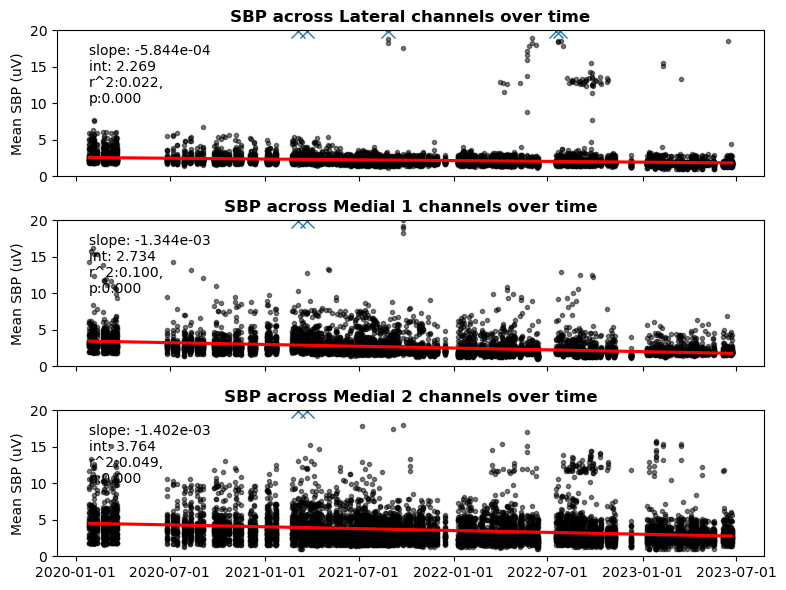

In [4]:
create_signal_quality_across_regions_figure(False, annotate=True)

['2021-07-16_preprocess.pkl', '2021-11-29_preprocess.pkl', '2023-06-16_preprocess.pkl', '2021-09-06_preprocess.pkl', '2023-04-05_preprocess.pkl', '2020-03-19_preprocess.pkl', '2021-03-13_preprocess.pkl', '2021-04-02_preprocess.pkl', '2021-08-23_preprocess.pkl', '2022-02-25_preprocess.pkl', '2020-03-18_preprocess.pkl', '2020-08-29_preprocess.pkl', '2022-09-06_preprocess.pkl', '2020-03-13_preprocess.pkl', '2022-10-25_preprocess.pkl', '2021-03-09_preprocess.pkl', '2022-09-09_preprocess.pkl', '2023-02-13_preprocess.pkl', '2021-02-23_preprocess.pkl', '2022-03-31_preprocess.pkl', '2021-03-12_preprocess.pkl', '2023-03-17_preprocess.pkl', '2021-08-27_preprocess.pkl', '2022-04-21_preprocess.pkl', '2021-04-21_preprocess.pkl', '2020-09-04_preprocess.pkl', '2022-01-26_preprocess.pkl', '2021-04-09_preprocess.pkl', '2021-11-01_preprocess.pkl', '2021-05-04_preprocess.pkl', '2023-02-20_preprocess.pkl', '2020-07-29_preprocess.pkl', '2022-04-08_preprocess.pkl', '2021-06-04_preprocess.pkl', '2021-08-31_p

100%|██████████| 303/303 [00:11<00:00, 26.24it/s]


0      True
1      True
2      True
3      True
4      True
       ... 
298    True
299    True
300    True
301    True
302    True
Length: 303, dtype: bool


findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson

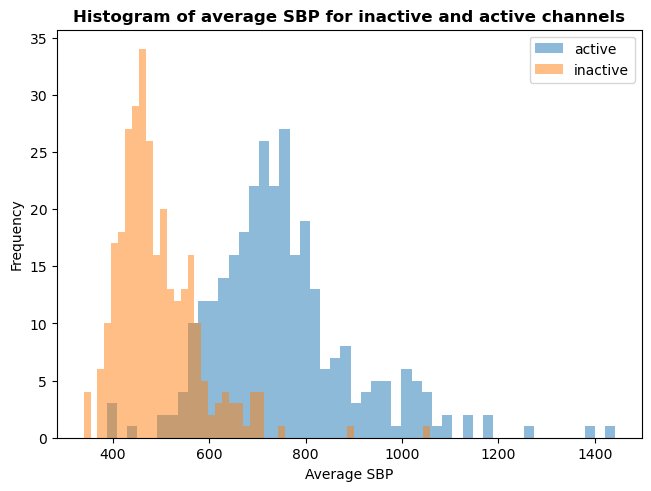

findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson

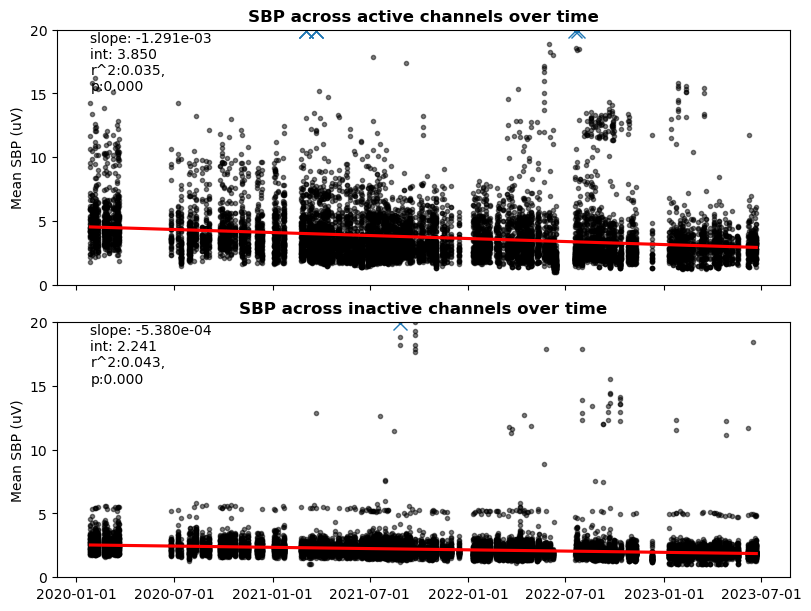

In [5]:
create_signal_quality_across_activities_figure(True, annotate=True)

In [6]:
data_path = "../../../AdaptiveAlignment/data/hisham_good_days/datasets/raw_data"
import re

def extract_dates_and_runs_from_filenames():
    print(os.listdir(data_path))
    # Find all matching .pkl files
    pkl_files = glob.glob(os.path.join(data_path, '*_preprocess.pkl'))

    dates = []
    runs = []
    for file_path in pkl_files:
        filename = os.path.basename(file_path)
        match = re.match(r'(\d{4}-\d{2}-\d{2})_preprocess\.pkl', filename)
        if match:
            dates.append(match.group(1))
            
        # print(dates[-1])
            
        file = os.path.join(data_path, f'{dates[-1]}_preprocess.pkl')

        with open(file, 'rb') as f:
            data_CO, data_RD = pickle.load(f)
            
        if data_CO and data_RD:
            runs.append([data_RD['run_id'], data_CO['run_id']])
        elif data_RD:
            runs.append(data_RD['run_id'])
        else:
            runs.append(data_CO['run_id'])

    dates = np.asarray([datetime.strptime(date, '%Y-%m-%d') for date in dates])
    return dates, runs

dates, runs = extract_dates_and_runs_from_filenames() 

['2021-07-16_preprocess.pkl', '2021-11-29_preprocess.pkl', '2023-06-16_preprocess.pkl', '2021-09-06_preprocess.pkl', '2023-04-05_preprocess.pkl', '2020-03-19_preprocess.pkl', '2021-03-13_preprocess.pkl', '2021-04-02_preprocess.pkl', '2021-08-23_preprocess.pkl', '2022-02-25_preprocess.pkl', '2020-03-18_preprocess.pkl', '2020-08-29_preprocess.pkl', '2022-09-06_preprocess.pkl', '2020-03-13_preprocess.pkl', '2022-10-25_preprocess.pkl', '2021-03-09_preprocess.pkl', '2022-09-09_preprocess.pkl', '2023-02-13_preprocess.pkl', '2021-02-23_preprocess.pkl', '2022-03-31_preprocess.pkl', '2021-03-12_preprocess.pkl', '2023-03-17_preprocess.pkl', '2021-08-27_preprocess.pkl', '2022-04-21_preprocess.pkl', '2021-04-21_preprocess.pkl', '2020-09-04_preprocess.pkl', '2022-01-26_preprocess.pkl', '2021-04-09_preprocess.pkl', '2021-11-01_preprocess.pkl', '2021-05-04_preprocess.pkl', '2023-02-20_preprocess.pkl', '2020-07-29_preprocess.pkl', '2022-04-08_preprocess.pkl', '2021-06-04_preprocess.pkl', '2021-08-31_p

In [7]:
print(len(dates))
print(len(runs))
print(runs)
# runs = [x for item in runs for x in (item if isinstance(item, list) else [item])]
# print(runs)

303
303
[3, 2, 3, 5, 3, 4, 11, 4, 2, [2, 11], 4, 4, 3, 3, 1, 2, 2, 2, 2, 4, 3, 3, 2, 1, 3, 4, 2, 2, 6, 2, 1, 3, [3, 15], 4, 3, [12, 10], 2, 2, 3, 2, 5, 5, 6, 2, 17, 2, 2, 2, 1, 2, 1, 3, 2, [7, 2], 2, 2, 3, 2, 3, 10, 2, 3, 2, 6, 7, 2, 4, 2, 2, 5, 3, 2, 15, 8, 3, 3, 2, 2, 2, 2, 2, 3, 3, 3, 5, 5, 3, 3, 1, 3, 8, 2, 3, 2, 2, 2, 5, 7, 3, 2, 2, 2, 2, 2, 2, 3, 2, 7, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 3, 3, 2, 2, 3, 2, 2, 2, 3, 6, 3, 3, [3, 12], 2, 3, 3, 6, 2, 3, 3, 3, 2, 3, 2, 4, 3, 8, 3, 3, 4, 3, 3, 2, 3, 2, 4, 6, 2, 2, 4, 5, 3, 3, 3, 3, 3, 2, 2, 3, 2, 3, 4, 3, 3, 4, 2, 3, 1, 1, 14, 3, 2, 2, 2, 3, 9, 5, 5, 4, 3, 3, 3, 3, 2, 3, 4, 2, 2, 2, 3, 3, 3, 2, 2, 2, 6, 3, 2, 7, 3, 2, 9, [14, 15], 4, 3, 3, 2, 8, 2, 6, 3, 1, 3, 3, 3, 2, 2, 3, 2, 3, 3, 7, 4, 4, 6, 2, 2, 1, 5, 5, 3, 3, 2, 3, 2, 6, 3, 2, 5, 2, 3, 2, 2, [10, 11], 2, 8, 2, 2, 2, 3, 9, 7, 10, 2, 2, 2, 5, 3, 2, 2, 2, 5, 5, 3, 2, 3, 10, 4, 3, 2, 6, 2, 2, 2, [6, 7], 5, 3, 3, 2, 6, 2, 3, 2, 5, 2, [3, 19], 3, 2, 4, 1, 2, 1, 4, 3, 3]


In [8]:

# dates = signal_utils.extract_dates_from_filenames()

In [ ]:
PATH = os.path.join("..", "..", "..", "..", "..", "..", "..","run", "user", "1000", "gvfs", 'smb-share:server=cnpl-drmanhattan.engin.umich.edu,share=share', "data", "monkeys", "Joker")

from scipy.io import loadmat
import h5py

def get_h5py(zFullPath):

    targs = []
    with h5py.File(zFullPath, 'r') as f: # opens the file
        data = f.get('/z/TargetScaling')
       
        for i in range(len(data[:])): #this part derefrences the HDF5 so you can see the data
            st = data[i][0]
            obj = f[st]
            targs.append(obj[:])

    if (targs == targs[0]).all():
        targ = targs[0]
    else:
        targ = list(np.unique(targs))
        print(f"inconsistencies: {targ}")
    return targ
def get_targ(d, r):
    p = os.path.join(PATH, f"{d.date()}", f"Run-{r:03d}")
       
    try:
        f = loadmat(os.path.join(p, f"Z_Joker_{d.date()}_Run-{r:03d}.mat")) 
        targ = f['z']['TargetScaling'][0][0][0][0]
        if (f['z']['TargetScaling'][0] ==targ).all() is False:
            targ = list(np.unique(f['z']['TargetScaling'][0]))
            print(f"inconsistencies: {targ}")

    except FileNotFoundError:
        print("Load npy")
        f = np.load(os.path.join(p, f"Z_Joker_{d.date()}_Run-{r:03d}.npy"), allow_pickle = True)
        targ = f[0].TargetScaling
        # targs.append(targ)
        ts = [f[i].TargetScaling for i in range(f.shape[0])]
        if (ts == targ).all() is False:
            targ = list(np.unique(ts))
            print(f"inconsistencies: {targ}")


    except NotImplementedError:
        f = os.path.join(p, f"Z_Joker_{d.date()}_Run-{r:03d}.mat")
        targ = get_h5py(f)
        # print(a)
        
    return targ

targs = []
t_dates = []
for i, (d, r) in enumerate(zip(dates, runs)):
    print(d)
    print(r)
    print(i)
    if isinstance(r, list):
        targs.append(get_targ(d, r[0]))
        targs.append(get_targ(d, r[1]))
        t_dates.append(d.date())
        t_dates.append(d.date())

    else: 
        targs.append(get_targ(d, r))
        t_dates.append(d.date())
        # p = os.path.join(path, f"{d.date()}", f"Run-{r:03d}")
       

2021-07-16 00:00:00
3
0
2021-11-29 00:00:00
2
1
2023-06-16 00:00:00
3
2
Load npy
